In [1]:
import torch 
from torch import nn
import numpy as np
import pandas as pd
import dataclasses
from dataclasses import dataclass, field
from typing import List
from torch.utils.data import Dataset, DataLoader, TensorDataset
from collections.abc import Iterable
from basic_conv1d import bn_drop_lin
from clinical_ts.template_modules import ShapeConfig
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix, roc_curve, auc
import sys
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import matplotlib
matplotlib.use('Agg')
import os
import warnings
warnings.filterwarnings('ignore')
import mlp_models
from scipy.interpolate import make_interp_spline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)
from xgboost import XGBClassifier

In [2]:
# Get the absolute path of the parent folder (MD-F)
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

# Add it to Python's search path if it's not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# --- NOW your existing imports will work perfectly ---
from template_modules import EncoderStaticBase, EncoderStaticBaseConfig
from mlp_models import BasicEncoderStaticMLP

# Table of content
## 1. Model initialization 
## 2. Loading the model
## 3. Extract ICU_24h predictions 
## 4. Class predictions at different thresholds using the BasicEncoderStaticMLP
## 5. Monte Carlo Dropout for calculating uncertainty

#  1. Model initialization (BasicEncoderStaticMLP)

In [3]:

# ----------------------------------------
@dataclass
class MLPConfig:
    embedding_dims: List[int] = field(default_factory=lambda: [16, 16, 16])
    vocab_sizes: List[int]    = field(default_factory=lambda: [2, 5, 5])
    lin_ftrs: List[int]       = field(default_factory=lambda: [128, 128, 128])
    dropout: float = 0.5
    batch_norm: bool = True

@dataclass
class ShapeCfg:
    static_dim: int = 0
    static_dim_cat: int = 0
    channels: int = 0
    length: int = 0
    sequence_last: bool = False
    channels2: int = 0

## 2. Loading the model

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
model_path = os.path.join(os.getcwd(), "best_realmlp.pt")
print(model_path, os.path.exists(model_path))  # sanity check — should print True

encoder = torch.load(
    model_path,
    map_location=device,
    weights_only=False
)

c:\Users\Taki Djebbar\Documents\Data Science S1\Medical Data Analysis with Deep Learning\Python scripts\MDS-ED\best_realmlp.pt True


In [6]:
DATA_PATH   = r'C:\Users\Taki Djebbar\Documents\Data Science S1\Medical Data Analysis with Deep Learning\Other\mds_ed.csv'
BATCH_SIZE = 64
# ============================================================
# 1. Load & preprocess data
# ============================================================
print("\nLoading data...")
df = pd.read_csv(DATA_PATH, low_memory=False)

input_cols    = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]
df_train      = df[df['general_strat_fold'] < 18]
train_medians = df_train[input_cols].median().to_dict()
for c in [c for c, v in df_train[input_cols].isna().sum().items() if v > 0]:
    df.loc[df[c].isna(), c] = train_medians[c]
df = df.copy()

unique_counts = {c: len(np.unique(np.array(df[c]))) for c in input_cols}
cat_features  = [c for c, v in unique_counts.items()
                 if v < 10 and not c.endswith("nan") and not c.startswith("labvalues")]
cont_features = [c for c in input_cols if c not in cat_features]

df["vitals_acuity"] = df["vitals_acuity"].apply(lambda x: int(x) - 1)
lbl_eth = ['demographics_ethnicity_asian','demographics_ethnicity_black/african',
           'demographics_ethnicity_hispanic/latino','demographics_ethnicity_other',
           'demographics_ethnicity_white']
df["demographics_ethnicity"] = df.apply(lambda r: np.where([r[c] for c in lbl_eth])[0][0], axis=1)
df.drop(lbl_eth, axis=1, inplace=True)

input_cols    = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]
cat_features  = [c for c in input_cols if c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

lbl_itos = ["mortality_365d", "icu_24h", "cardiac_arrest", "vasopressors"]
for c in lbl_itos:
    df["deterioration_" + c] = df["deterioration_" + c].replace(-999., np.nan)

val_df  = df[df['general_strat_fold'] == 18].reset_index(drop=True)
test_df = df[df['general_strat_fold'] == 19].reset_index(drop=True)
val_df  = val_df[val_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
test_df = test_df[test_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
print(f"Val: {len(val_df)}, Test: {len(test_df)}")

# ============================================================
# 2. Dataset & DataLoader
# ============================================================
class TabularDataset(Dataset):
    def __init__(self, df, cont_f, cat_f, lbl_cols):
        self.cont   = torch.tensor(df[cont_f].values, dtype=torch.float32)
        self.cat    = torch.tensor(df[cat_f].values,  dtype=torch.long)
        self.labels = torch.tensor(df[["deterioration_"+c for c in lbl_cols]].values, dtype=torch.float32)
    def __len__(self): return len(self.cont)
    def __getitem__(self, i): return self.cont[i], self.cat[i], self.labels[i]

val_loader  = DataLoader(TabularDataset(val_df,  cont_features, cat_features, lbl_itos),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(TabularDataset(test_df, cont_features, cat_features, lbl_itos),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0)



Loading data...
Val: 5824, Test: 6080


# 3. Extract ICU_24h predictions 

In [7]:

# Predict on validation set
# ----------------------------------------
all_preds, all_labels = [], []

with torch.no_grad():

    for cont, cat, labels in val_loader:

        cont = cont.to(device)
        cat  = cat.to(device)

        out = encoder(static=cont, static_cat=cat)

        probs = torch.sigmoid(out["static"])

        all_preds.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)


# ----------------------------------------
# Extract ICU_24h predictions and labels
# ----------------------------------------
target_idx = 1

mask = ~np.isnan(all_labels[:, target_idx])

y_true = all_labels[:, target_idx]
y_prob = all_preds[:, target_idx]


# ----------------------------------------
# Save to CSV
# ----------------------------------------
results = pd.DataFrame({
    "ICU_24h_true": y_true.astype(int),
    "ICU_24h_probability": y_prob
})


print(results)


      ICU_24h_true  ICU_24h_probability
0                1             0.003544
1                0             0.009340
2                0             0.009667
3                0             0.131255
4                0             0.137423
...            ...                  ...
5819             0             0.021627
5820             0             0.226714
5821             0             0.034652
5822             1             0.031389
5823             0             0.005518

[5824 rows x 2 columns]


# 4. Class predictions at different thresholds using the BasicEncoderStaticMLP

## 4.1 threshold function to calculate FP, FN, TP, TN

In [8]:

# Set diffrent thresholds from 0 all the way to 1
def evaluate_thresholds(y_true, y_prob, thresholds=np.arange(0.01, 1, 0.01), cFP=1,
    cFN=1):
    
    results = []

    for thr in thresholds:

        y_pred = (y_prob >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        sensitivity = tp / (tp + fn )   # recall
        specificity = tn / (tn + fp )

        precision = tp / (tp + fp)
        # Cost function
        cost = cFP * fp + cFN * fn

        results.append({
            "threshold": thr,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "False Positive": fp,
            "True Positive": tp,
            "False Negative": fn,
            "True Negative": tn,
            "cost": cost
        })

    return pd.DataFrame(results)

## 4.2 Confusion matrix + sensitivity + specificity for icu_24h using MLP

In [9]:
all_results = []

label_name = ['icu_24h']


mask = ~np.isnan(all_labels[:, 1])
y_true = all_labels[mask, 1]
y_prob = all_preds[mask, 1]

df_thr = evaluate_thresholds(y_true, y_prob, cFP=1, cFN=1)

# Force a completely independent copy and assign label
df_temp = df_thr[[
    "threshold",
    "sensitivity",
    "specificity",
    "precision",
    "False Positive",
    "False Negative",
    "cost"
]].copy()

print("\n")
print("=" * 60)
print(label_name)
print("=" * 60)

result_icu_prediction = df_temp

print(result_icu_prediction.head())



['icu_24h']
   threshold  sensitivity  specificity  precision  False Positive  \
0       0.01     0.993921     0.200621   0.137107            4116   
1       0.02     0.972644     0.390173   0.169312            3140   
2       0.03     0.951368     0.514275   0.200192            2501   
3       0.04     0.925532     0.598757   0.227664            2066   
4       0.05     0.910334     0.659934   0.254894            1751   

   False Negative  cost  
0               4  4120  
1              18  3158  
2              32  2533  
3              49  2115  
4              59  1810  


### 4.3 ROC curve (sensitivity vs specificity)

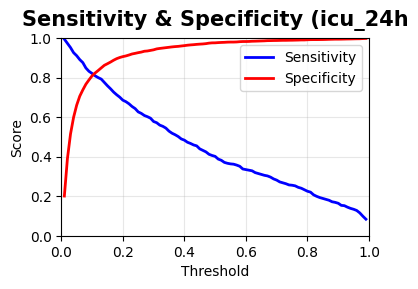

In [10]:
%matplotlib inline
df_mlp = result_icu_prediction
plt.figure(figsize=(4,3))
plt.plot(df_mlp["threshold"], df_mlp["sensitivity"], label="Sensitivity", color="blue", linewidth=2)
plt.plot(df_mlp["threshold"], df_mlp["specificity"], label="Specificity", color="red", linewidth=2)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)

plt.title("Sensitivity & Specificity (icu_24h", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.4 ROC Curve for all labels

In [11]:
label_names=["mortality_365d", "icu_24h", "cardiac_arrest", "vasopressors"]

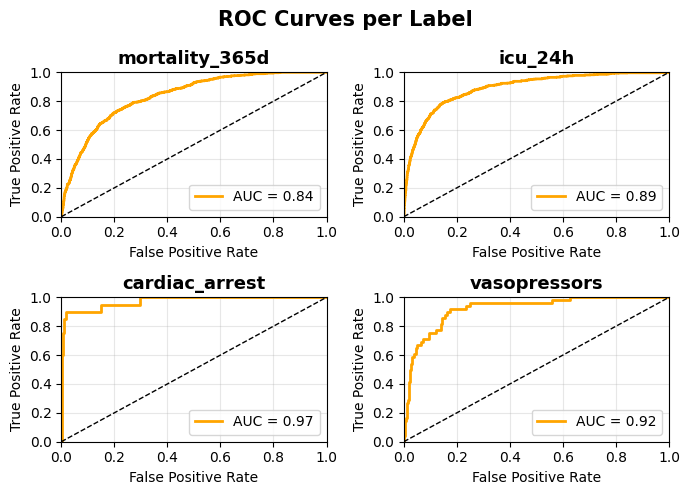

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

for i, label_name in enumerate(label_names):
    mask = ~np.isnan(all_labels[:, i])
    y_true = all_labels[mask, i]
    y_prob = all_preds[mask, i]

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, color="orange", linewidth=2, label=f"AUC = {roc_auc:.2f}")
    axes[i].plot([0, 1], [0, 1], "--", color="black", linewidth=1)

    axes[i].set_title(label_name, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("False Positive Rate")
    axes[i].set_ylabel("True Positive Rate")
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].legend(loc="lower right")
    axes[i].grid(True, alpha=0.3)

plt.suptitle("ROC Curves per Label", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("roc_curves_subplots.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. Monte Carlo Dropout 

In [13]:
def mc_dropout_predict(model, test_loader, device, n_samples=50):

    model.train()  # IMPORTANT: keep dropout active

    all_mean_preds = []
    all_uncertainties = []
    all_labels = []

    with torch.no_grad():

        for cont, cat, labels in test_loader:

            cont = cont.to(device)
            cat  = cat.to(device)

            mc_samples = []

            # ----------------------------------------
            # Multiple stochastic forward passes
            # ----------------------------------------
            for _ in range(n_samples):

                out = model(static=cont, static_cat=cat)
                probs = torch.sigmoid(out["static"])

                mc_samples.append(probs.cpu().numpy())

            mc_samples = np.array(mc_samples)

            # -------------
            # 
            # ---------------------------
            # MC statistics
            # ----------------------------------------
            mean_preds = mc_samples.mean(axis=0)
            uncertainty = mc_samples.std(axis=0)

            all_mean_preds.append(mean_preds)
            all_uncertainties.append(uncertainty)
            all_labels.append(labels.numpy())

    all_mean_preds = np.concatenate(all_mean_preds, axis=0)
    all_uncertainties = np.concatenate(all_uncertainties, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_mean_preds, all_uncertainties, all_labels

In [28]:
print("\nRunning Monte Carlo Dropout...")

all_mean_preds, all_uncertainties, y_true = mc_dropout_predict(
    encoder,
    test_loader,
    device,
    n_samples=50
)


Running Monte Carlo Dropout...


### 5.1 exclude labels with nan values

In [29]:
y_test = y_true[:, 1]
pred_prob = all_mean_preds[:, 1]

mask = ~np.isnan(y_test)

y_test = y_test[mask]
pred_prob = pred_prob[mask]


y_class = (pred_prob >= 0.14).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_class).ravel()
print(f"Baseline FP = {fp}")

Baseline FP = 897


### 5.2 Uncertainty distribution across TP and FP

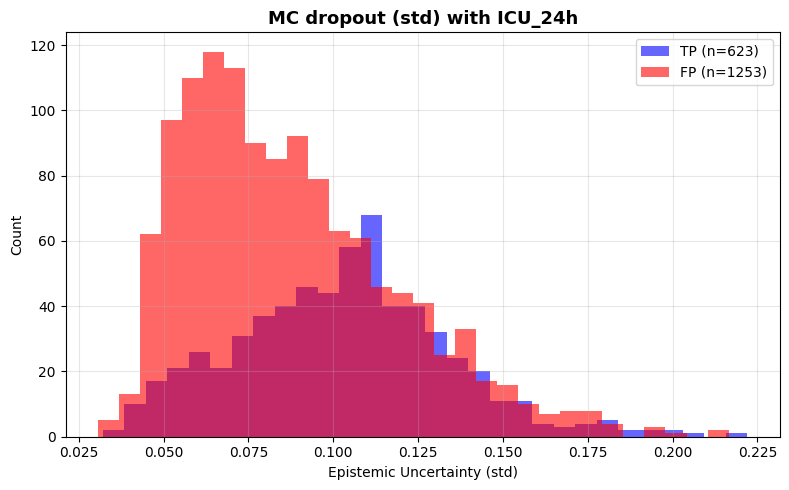

In [30]:
threshold=0.1  # sensitivity = 80%
mask = ~np.isnan(y_true[:, 1])

y_true_i      = y_true[mask, 1]
mean_preds_i  = all_mean_preds[mask, 1]
uncertainty_i = all_uncertainties[mask, 1]

# Classify into TP and FP
predicted_pos = mean_preds_i >= threshold
tp_mask       = (predicted_pos) & (y_true_i == 1)
fp_mask       = (predicted_pos) & (y_true_i == 0)

tp_uncertainty = uncertainty_i[tp_mask]
fp_uncertainty = uncertainty_i[fp_mask]

plt.figure(figsize=(8, 5))
plt.hist(tp_uncertainty, bins=30, alpha=0.6, color="blue", label=f"TP (n={tp_mask.sum()})")
plt.hist(fp_uncertainty, bins=30, alpha=0.6, color="red",  label=f"FP (n={fp_mask.sum()})")

plt.title("MC dropout (std) with ICU_24h", fontsize=13, fontweight="bold")
plt.xlabel("Epistemic Uncertainty (std)")
plt.ylabel("Count")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("uncertainty_tp_fp_icu_24h.png", dpi=150, bbox_inches="tight")
plt.show()